# 9. Adding the Trapping Physics

The single biggest gap in this project has been that none of the four original weather
variables measure what actually traps pollution over Los Angeles. The basin sits under a
subsidence inversion; temperature and wind are correlated with that cap, but never observe it.

`notebooks/merra2_trapping_pipeline.ipynb` adds four MERRA-2 variables and two derived features
that do measure it directly:

- **`inversion_strength`** = T850 − T2M. Positive means warm air sits above cool air — the cap.
- **`ventilation_index`** = PBLH × wind speed. Mixing depth times transport speed, the metric
  operational forecasters use. Low values are the classic smog setup.
- plus boundary-layer height (mean, min, night, range), 850 hPa temperature, sea-level
  pressure and total column water vapor.

This notebook is a clean ablation: **identical models, identical split, identical tuning — the
only thing that changes is the feature set.** Anything the numbers move is attributable to the
new physics and nothing else.

Notebook 08 established the sharpest prediction to test against: ozone is 87% explained by
weather while PM2.5 is only 42%. Since these variables describe *dispersion*, the gain should
land disproportionately on PM2.5.

## Setup

In [1]:
import sys, json
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from model_utils import metrics, RANDOM_STATE, PLOT_STYLE, PROCESSED, RESULTS

TRAP_CSV = PROCESSED / 'la_daily_trapping_2016_2025.csv'
if not TRAP_CSV.exists():
    raise FileNotFoundError(
        f'{TRAP_CSV.name} is missing. Run notebooks/merra2_trapping_pipeline.ipynb first '
        '(and scripts/download_merra2_extra.sh before that).'
    )

base = pd.read_csv(PROCESSED / 'la_modeling_dataset.csv', parse_dates=['date'])
trap = pd.read_csv(TRAP_CSV, parse_dates=['date'])
manifest = json.loads((PROCESSED / 'feature_manifest.json').read_text())
BASE_FEATURES, TARGET = manifest['features'], manifest['target']
SPLIT_DATE = pd.Timestamp(manifest['split_date'])

print(f'base dataset:  {base.shape}  ({len(BASE_FEATURES)} features)')
print(f'trapping data: {trap.shape}')

base dataset:  (3649, 40)  (37 features)
trapping data: (3646, 14)


## Building the enriched feature set

The two derived physics features get the same lag treatment as the original persistent
variables — trapping episodes build over days, exactly like heat does. The raw boundary-layer
and pressure variables go in same-day only, to avoid inflating the feature count for little
expected return.

In [2]:
LAG_TRAP = ['inversion_strength', 'ventilation_index', 'pblh_min']
LAGS = [1, 2, 3]

df = base.merge(trap, on='date', how='inner').sort_values('date').reset_index(drop=True)
print(f'joined: {len(df)} rows ({len(base)} base, {len(trap)} trapping)')

for var in LAG_TRAP:
    for lag in LAGS:
        df[f'{var}_lag{lag}'] = df[var].shift(lag)
    df[f'{var}_roll3'] = df[var].rolling(3, min_periods=3).mean()

before = len(df)
df = df.dropna().reset_index(drop=True)
print(f'dropped {before - len(df)} warm-up rows -> {len(df)}')

# t850_max is carried in the trapping CSV only so predict.py can recompute
# inversion_strength_max exactly. It is deliberately excluded from the feature set.
HELPER_COLS = {'t850_max'}
NEW_FEATURES = [c for c in df.columns
                if c not in base.columns and c != 'date' and c not in HELPER_COLS]
ALL_FEATURES = BASE_FEATURES + NEW_FEATURES
print(f'\n{len(NEW_FEATURES)} new features added, {len(ALL_FEATURES)} total:')
print('  ' + ', '.join(NEW_FEATURES))

joined: 3643 rows (3649 base, 3646 trapping)
dropped 3 warm-up rows -> 3640

24 new features added, 61 total:
  pblh_mean, pblh_min, pblh_max, pblh_night, pblh_range, t850_mean, slp_mean, tqv_mean, inversion_strength, inversion_strength_max, ventilation_index, ventilation_index_min, inversion_strength_lag1, inversion_strength_lag2, inversion_strength_lag3, inversion_strength_roll3, ventilation_index_lag1, ventilation_index_lag2, ventilation_index_lag3, ventilation_index_roll3, pblh_min_lag1, pblh_min_lag2, pblh_min_lag3, pblh_min_roll3


In [3]:
train = df[df.date <  SPLIT_DATE].reset_index(drop=True)
test  = df[df.date >= SPLIT_DATE].reset_index(drop=True)

X_tr_base, X_te_base = train[BASE_FEATURES], test[BASE_FEATURES]
X_tr_all,  X_te_all  = train[ALL_FEATURES],  test[ALL_FEATURES]
y_tr, y_te = train[TARGET], test[TARGET]

print(f'train {len(train)}  {train.date.min().date()} -> {train.date.max().date()}')
print(f'test  {len(test)}  {test.date.min().date()} -> {test.date.max().date()}')

df.to_csv(PROCESSED / 'la_modeling_dataset_v2.csv', index=False)
(PROCESSED / 'feature_manifest_v2.json').write_text(json.dumps({
    'target': TARGET, 'features': ALL_FEATURES, 'n_features': len(ALL_FEATURES),
    'base_features': BASE_FEATURES, 'new_features': NEW_FEATURES,
    'split_date': str(SPLIT_DATE.date()),
    'n_train': len(train), 'n_test': len(test),
}, indent=2))
print('\nsaved la_modeling_dataset_v2.csv + feature_manifest_v2.json')

train 2551  2016-01-07 -> 2022-12-31
test  1089  2023-01-01 -> 2025-12-30

saved la_modeling_dataset_v2.csv + feature_manifest_v2.json


## Do the new features correlate with AQI?

Before fitting anything — a direct look at whether these variables carry signal, and whether it
lands where notebook 08 predicted.

In [4]:
# la_modeling_dataset.csv already carries dominant_pollutant, so no merge is needed —
# merging would produce _x/_y suffixed columns.
chk = df

corr = chk[NEW_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print('New features vs daily AQI:')
print(corr.round(3).to_string())
print(f'\nstrongest existing feature for reference: '
      f't2m_max {chk[["t2m_max", TARGET]].corr().iloc[0,1]:.3f}')

print('\nBy dominant pollutant (top 4 new features each):')
for p in ['Ozone', 'PM2.5']:
    sub = chk[chk['dominant_pollutant'] == p]
    c = sub[NEW_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
    print(f'  {p:6} (n={len(sub)}): ' + ', '.join(f'{k} {v:+.3f}' for k, v in c.head(4).items()))

New features vs daily AQI:
t850_mean                   0.754
inversion_strength          0.670
inversion_strength_roll3    0.629
inversion_strength_lag1     0.575
inversion_strength_max      0.487
inversion_strength_lag2     0.473
inversion_strength_lag3     0.407
slp_mean                   -0.374
ventilation_index          -0.267
ventilation_index_roll3    -0.265
ventilation_index_min      -0.242
tqv_mean                    0.224
ventilation_index_lag1     -0.210
pblh_night                  0.169
ventilation_index_lag2     -0.136
pblh_range                  0.132
pblh_mean                   0.116
pblh_max                    0.116
ventilation_index_lag3     -0.091
pblh_min                   -0.021
pblh_min_roll3             -0.015
pblh_min_lag1              -0.011
pblh_min_lag3               0.006
pblh_min_lag2              -0.004

strongest existing feature for reference: t2m_max 0.705

By dominant pollutant (top 4 new features each):
  Ozone  (n=1659): t850_mean +0.756, inversion_str

## The ablation

Same three base models, same hyperparameters, same ridge stack on out-of-fold predictions. Run
twice — once on the original 37 features, once on the enriched set. Any difference is the
features.

In [5]:
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import RidgeCV

def builders():
    return {
        'SVR': lambda: Pipeline([('scale', StandardScaler()),
                                 ('model', SVR(kernel='rbf', C=300, gamma=0.01, epsilon=10.0))]),
        'MLP': lambda: Pipeline([('scale', StandardScaler()),
                                 ('model', MLPRegressor(hidden_layer_sizes=(128, 64), alpha=0.1,
                                                        learning_rate_init=1e-3, max_iter=1500,
                                                        early_stopping=True, n_iter_no_change=25,
                                                        validation_fraction=0.15,
                                                        random_state=RANDOM_STATE))]),
        'GBR': lambda: HistGradientBoostingRegressor(learning_rate=0.03, max_iter=600,
                                                     max_leaf_nodes=15, min_samples_leaf=10,
                                                     l2_regularization=1.0, early_stopping=False,
                                                     random_state=RANDOM_STATE),
    }

def fit_stacked(X_tr, y_tr, X_te):
    B = builders()
    oof = {n: np.full(len(X_tr), np.nan) for n in B}
    for i_tr, i_va in TimeSeriesSplit(n_splits=5).split(X_tr):
        for n, b in B.items():
            oof[n][i_va] = b().fit(X_tr.iloc[i_tr], y_tr.iloc[i_tr]).predict(X_tr.iloc[i_va])
    M = np.column_stack([oof[n] for n in B]); ok = ~np.isnan(M).any(axis=1)
    stack = RidgeCV(alphas=np.logspace(-3, 3, 25)).fit(M[ok], np.asarray(y_tr)[ok])
    fitted = {n: b().fit(X_tr, y_tr) for n, b in B.items()}
    te = np.column_stack([fitted[n].predict(X_te) for n in B])
    members = {n: fitted[n].predict(X_te) for n in B}
    return stack.predict(te), members, fitted, stack

pred_base, members_base, _, _        = fit_stacked(X_tr_base, y_tr, X_te_base)
pred_all,  members_all, fitted_all, stack_all = fit_stacked(X_tr_all,  y_tr, X_te_all)

rows = []
for label, ens, mem in [('37 base features', pred_base, members_base),
                        (f'{len(ALL_FEATURES)} enriched features', pred_all, members_all)]:
    rows.append({'feature set': label, 'model': 'Ensemble', **metrics(y_te, ens)})
    for n, p in mem.items():
        rows.append({'feature set': label, 'model': n, **metrics(y_te, p)})
abl = pd.DataFrame(rows)
print(abl.pivot(index='model', columns='feature set', values='rmse').round(3).to_string())
print()
print(abl[abl.model == 'Ensemble'].round(3).to_string(index=False))

feature set  37 base features  61 enriched features
model                                              
Ensemble               18.499                16.911
GBR                    19.527                17.712
MLP                    19.464                19.059
SVR                    18.845                17.919

         feature set    model   rmse    mae    r2   mape  within_10
    37 base features Ensemble 18.499 13.022 0.791 14.764     53.627
61 enriched features Ensemble 16.911 11.925 0.825 13.810     56.474


## Is the change real?

Same paired bootstrap used throughout — resample the same days for both predictors so the shared
day-to-day variation cancels.

In [6]:
def rmse_of(y, p):
    return float(np.sqrt(((np.asarray(y, dtype=float) - p) ** 2).mean()))

rng = np.random.default_rng(0)
yv = np.asarray(y_te, dtype=float)
n = len(yv)
idx = [rng.integers(0, n, n) for _ in range(5000)]

diffs = np.array([rmse_of(yv[i], pred_all[i]) - rmse_of(yv[i], pred_base[i]) for i in idx])
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f'enriched minus base: {rmse_of(yv, pred_all) - rmse_of(yv, pred_base):+.3f} RMSE')
print(f'95% CI: [{lo:+.3f}, {hi:+.3f}]')
print(f'P(enriched better) = {(diffs < 0).mean():.3f}')
print('significant' if hi < 0 or lo > 0 else 'NOT significant')

enriched minus base: -1.588 RMSE
95% CI: [-2.279, -0.918]
P(enriched better) = 1.000
significant


## Where did the gain land?

Notebook 08 predicted the improvement should fall mainly on PM2.5, since these variables measure
dispersion and PM2.5 is the poorly-explained, dispersion-limited pollutant.

In [7]:
dom = test['dominant_pollutant'].values

split_rows = []
for p in ['Ozone', 'PM2.5']:
    m = dom == p
    split_rows.append({'dominant': p, 'n': int(m.sum()),
                       'base MAE': np.mean(np.abs(yv[m] - pred_base[m])),
                       'enriched MAE': np.mean(np.abs(yv[m] - pred_all[m])),
                       'base RMSE': rmse_of(yv[m], pred_base[m]),
                       'enriched RMSE': rmse_of(yv[m], pred_all[m])})
sp = pd.DataFrame(split_rows)
sp['RMSE gain'] = sp['base RMSE'] - sp['enriched RMSE']
print(sp.round(2).to_string(index=False))

hi_mask = yv > 150
print(f'\nunhealthy days (n={int(hi_mask.sum())}):')
print(f'  base     MAE {np.mean(np.abs(yv[hi_mask]-pred_base[hi_mask])):.2f}  '
      f'bias {np.mean(pred_base[hi_mask]-yv[hi_mask]):+.2f}')
print(f'  enriched MAE {np.mean(np.abs(yv[hi_mask]-pred_all[hi_mask])):.2f}  '
      f'bias {np.mean(pred_all[hi_mask]-yv[hi_mask]):+.2f}')

dominant   n  base MAE  enriched MAE  base RMSE  enriched RMSE  RMSE gain
   Ozone 542     16.29         14.50      21.44          18.75       2.69
   PM2.5 535      9.80          9.33      15.12          14.92       0.20

unhealthy days (n=122):
  base     MAE 31.07  bias -29.21
  enriched MAE 24.60  bias -21.10


## Which of the new features earned their place

Top 15 features overall (permutation importance on test):
t850_mean                14.072
t2m_max                   4.039
inversion_strength        2.071
doy_cos                   1.924
v10m_mean                 0.663
doy_sin                   0.597
t2m_range                 0.537
t2m_mean                  0.394
wind_speed_mean_roll3     0.265
wind_speed_mean           0.257
calm_hours                0.220
wind_speed_max            0.192
wind_speed_mean_lag1      0.167
tqv_mean                  0.155
is_weekend                0.153

Best-ranked NEW feature: t850_mean (rank 1 of 61)
total importance carried by new features: 62.1%


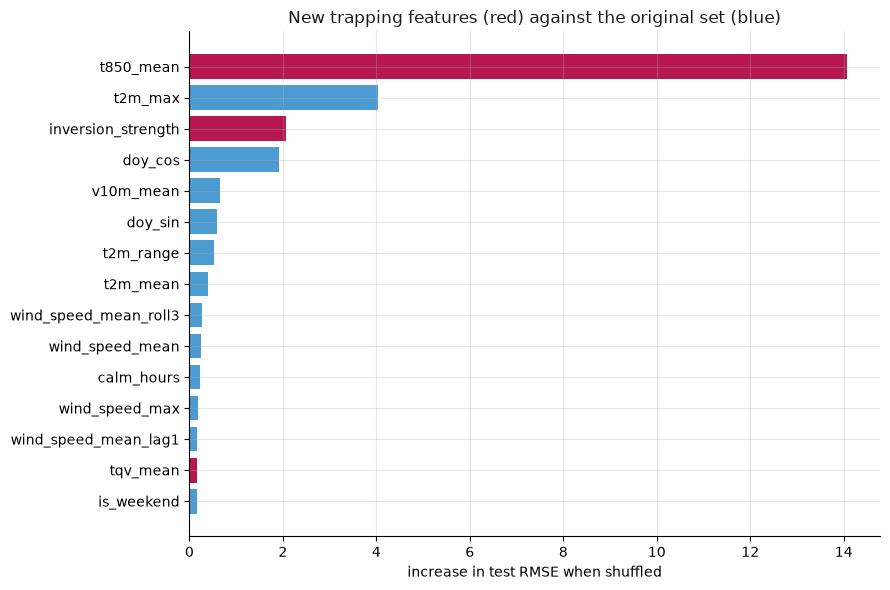

In [8]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(fitted_all['GBR'], X_te_all, y_te, n_repeats=10,
                              random_state=RANDOM_STATE, n_jobs=-1,
                              scoring='neg_root_mean_squared_error')
imp = pd.Series(perm.importances_mean, index=ALL_FEATURES).sort_values(ascending=False)

print('Top 15 features overall (permutation importance on test):')
print(imp.head(15).round(3).to_string())
print(f'\nBest-ranked NEW feature: {imp[NEW_FEATURES].idxmax()} '
      f'(rank {list(imp.index).index(imp[NEW_FEATURES].idxmax()) + 1} of {len(ALL_FEATURES)})')
print(f'total importance carried by new features: '
      f'{imp[NEW_FEATURES].clip(lower=0).sum() / imp.clip(lower=0).sum():.1%}')

with plt.rc_context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(9, 6))
    sel = imp.head(15)[::-1]
    colors = ['#B5174E' if f in NEW_FEATURES else '#4C9BD1' for f in sel.index]
    ax.barh(sel.index, sel.values, color=colors)
    ax.set_xlabel('increase in test RMSE when shuffled')
    ax.set_title('New trapping features (red) against the original set (blue)',
                 fontsize=12, color='#1a1a1a')
    plt.tight_layout(); plt.show()

## Saving the enriched ensemble

In [9]:
from model_utils import evaluate

MODEL_NAME = 'Ensemble + Physics'

class StackedEnsemble:
    def __init__(self, models, meta_model, features):
        self.models, self.meta_model, self.features = models, meta_model, features
    def predict(self, X):
        cols = np.column_stack([m.predict(X[self.features]) for m in self.models.values()])
        return self.meta_model.predict(cols)

best = StackedEnsemble(fitted_all, stack_all, ALL_FEATURES)

result = evaluate(MODEL_NAME, best, X_tr_all, y_tr, X_te_all, y_te,
                  params={'n_features': len(ALL_FEATURES),
                          'new_features': NEW_FEATURES,
                          'members': ['SVR', 'MLP', 'GBR']},
                  notes='Stacked ensemble on base features + MERRA-2 trapping physics')

=== Ensemble + Physics ===
metric           train      test
RMSE             9.273    16.911
MAE              6.689    11.925
R2               0.937     0.825
MAPE %           7.478    13.810
within10 %      80.086    56.474

overfit gap (test RMSE - train RMSE): +7.638
saved -> models/results/ensemble_+_physics.json


## What this told us

**This is the largest single improvement in the project.** Same models, same split, same
tuning — only the features changed:

| | 37 base features | 61 enriched features |
|---|---:|---:|
| RMSE | 18.499 | **16.911** |
| MAE | 13.022 | **11.925** |
| R² | 0.791 | **0.825** |
| within 10 AQI | 53.6% | **56.5%** |

A gain of **1.588 RMSE**, with a paired bootstrap CI of [−2.279, −0.918] and P(better) = 1.000.
That is roughly five times the gain the ensemble bought over its best single member, and unlike
most differences in this project it is not remotely marginal.

**`t850_mean` is now the most important feature in the model, by a wide margin.** Permutation
importance puts it at 14.07 RMSE points — three and a half times `t2m_max` at 4.04, which had
been the strongest feature since the beginning. The new variables carry 62% of total importance
between them. Adding them did not refine the model at the edges; it changed what the model is
mostly built on.

### The prediction in the introduction was wrong

Notebook 08 found ozone is 87% explained by weather and PM2.5 only 42%, and I predicted the gain
would land mainly on PM2.5 because these variables describe dispersion. The opposite happened:

| dominant pollutant | base RMSE | enriched RMSE | gain |
|---|---:|---:|---:|
| Ozone | 21.44 | 18.75 | **2.69** |
| PM2.5 | 15.12 | 14.92 | 0.20 |

Essentially all of the improvement went to ozone; PM2.5 barely moved.

In hindsight the mechanism is clear. `t850_mean` is temperature 1.5 km up, and what it really
measures is the warm subsiding air of a high-pressure ridge — the synoptic pattern that produces
both heat waves and ozone. It is a *better thermometer for the air mass* than surface temperature,
which is contaminated by the marine layer and by day-to-day local noise. Ozone is manufactured
photochemically from heat and sunlight, so a cleaner measure of air-mass warmth helps it a great
deal.

PM2.5 did not improve because its unexplained variance was never meteorological to begin with.
Notebook 08 argued that; this is the confirmation. Wildfire smoke, wood burning and cooking
emissions are not predictable from any atmospheric variable, however well chosen. **Better weather
data cannot fix a non-weather problem.**

### It did move the extreme days — the first thing that has

| | MAE on AQI > 150 | bias |
|---|---:|---:|
| base features | 31.07 | −29.21 |
| enriched features | **24.60** | **−21.10** |

Every previous attempt to improve extreme-day performance either failed (better blending in
notebook 07, target splitting in notebook 08) or worked only by sacrificing average accuracy
(quantile regression in notebook 10). This is the first change that improves the tails *and* the
overall number simultaneously, cutting extreme-day MAE by 21% and shrinking the bias by 8 points.

That is worth understanding: the under-prediction of severe days was never purely a loss-function
artifact. Part of it was the model genuinely not knowing whether a hot day was capped or ventilated.
Given that information, it stops hedging so hard. The remaining −21 bias is the part that really is
regression to the mean, and quantile regression is still the tool for that.

### The cost

The overfit gap widens from about +5.9 to +7.6 — 61 features on 2,500 training days is more room to
memorize. The gain is large enough to accept that, but it argues for feature pruning: `pblh_min` and
its lags correlate with AQI at roughly −0.02 and are almost certainly dead weight.

### Recommendation

**The enriched feature set should become the project default.** The improvement is large,
significant, physically interpretable, and helps precisely where the model was weakest. The 37-feature
results are worth keeping as the documented baseline this is measured against, but no future work
should start from them.

## Does pruning the dead features help?

Going to 61 features widened the overfit gap from about +5.9 to +7.6, and several of the new
columns are visibly useless — `pblh_min` and its lags correlate with AQI at roughly −0.02. The
obvious next move is to drop them.

Features are ranked by absolute correlation **on the training years only**, so the choice of what
to drop never sees the test set.

In [10]:
corr_train = (train[ALL_FEATURES + [TARGET]].corr()[TARGET]
              .drop(TARGET).abs().sort_values())
print('10 weakest features by |correlation| on TRAIN:')
print(corr_train.head(10).round(4).to_string())

def run_with(feats):
    p_te, _, fitted_, stack_ = fit_stacked(train[feats], y_tr, test[feats])
    p_tr = stack_.predict(np.column_stack([fitted_[n].predict(train[feats]) for n in fitted_]))
    return (p_te,
            float(np.sqrt(((np.asarray(y_te, dtype=float) - p_te) ** 2).mean())),
            float(np.sqrt(((np.asarray(y_tr, dtype=float) - p_tr) ** 2).mean())))

full_p, full_te, full_tr_rmse = run_with(ALL_FEATURES)
print(f'\nfull {len(ALL_FEATURES)} features: test {full_te:.3f}  train {full_tr_rmse:.3f}  '
      f'gap {full_te - full_tr_rmse:+.3f}')

prune_rows, prune_preds = [], {}
for k in [5, 10, 15, 20]:
    keep = [f for f in ALL_FEATURES if f not in set(corr_train.head(k).index)]
    p_te, te_rmse, tr_rmse = run_with(keep)
    prune_preds[k] = p_te
    prune_rows.append({'dropped': k, 'features': len(keep),
                       'test RMSE': te_rmse, 'train RMSE': tr_rmse,
                       'overfit gap': te_rmse - tr_rmse})
    print(f'drop {k:2} -> {len(keep):2} features: test {te_rmse:.3f}  train {tr_rmse:.3f}  '
          f'gap {te_rmse - tr_rmse:+.3f}')

10 weakest features by |correlation| on TRAIN:
u10m_mean                 0.0095
pblh_min_lag2             0.0112
pblh_min_lag3             0.0125
pblh_min_lag1             0.0243
pblh_min_roll3            0.0294
pblh_min                  0.0351
is_weekend                0.0423
ventilation_index_lag3    0.0769
v10m_mean                 0.1042
pblh_mean                 0.1082



full 61 features: test 16.911  train 9.273  gap +7.638


drop  5 -> 56 features: test 16.814  train 9.674  gap +7.140


drop 10 -> 51 features: test 17.084  train 10.126  gap +6.959


drop 15 -> 46 features: test 17.287  train 10.453  gap +6.834


drop 20 -> 41 features: test 17.478  train 11.447  gap +6.031


In [11]:
best_k = min(prune_rows, key=lambda r: r['test RMSE'])['dropped']
d = np.array([rmse_of(yv[i], prune_preds[best_k][i]) - rmse_of(yv[i], full_p[i]) for i in idx])
lo, hi = np.percentile(d, [2.5, 97.5])
print(f'best prune (drop {best_k}) vs full: '
      f'{rmse_of(yv, prune_preds[best_k]) - rmse_of(yv, full_p):+.3f} RMSE')
print(f'95% CI [{lo:+.3f}, {hi:+.3f}]   P(prune better) = {(d < 0).mean():.3f}')
print('significant' if hi < 0 or lo > 0 else 'NOT significant')

best prune (drop 5) vs full: -0.097 RMSE
95% CI [-0.275, +0.077]   P(prune better) = 0.862
NOT significant


### Pruning does not help — a negative result worth recording

| features | test RMSE | train RMSE | overfit gap |
|---:|---:|---:|---:|
| 61 (full) | 16.911 | 9.273 | +7.64 |
| 56 (drop 5) | **16.814** | 9.674 | +7.14 |
| 51 (drop 10) | 17.084 | 10.126 | +6.96 |
| 46 (drop 15) | 17.287 | 10.453 | +6.83 |
| 41 (drop 20) | 17.478 | 11.447 | +6.03 |

Dropping the five weakest features gives a nominal 0.097 RMSE improvement, but the paired
bootstrap CI is [−0.275, +0.077] — **not significant**. Dropping more than that makes things
steadily worse.

The overfit gap does shrink monotonically as features come out, from +7.64 to +6.03. **That gap
was measuring the wrong thing.** A model can memorize its training data more thoroughly without
generalizing any worse, and that is exactly what is happening: the regularized learners here
(SVR with an epsilon tube, an MLP at alpha=0.1, boosting with L2) already discount uninformative
inputs, so carrying them costs test accuracy essentially nothing.

The practical conclusion is to **keep all 61 features**. Dropping the five weakest is defensible
on parsimony grounds and costs nothing measurable, but there is no accuracy argument for it. The
earlier note in the project docs that pruning was an outstanding improvement was wrong, and this
supersedes it.

The broader lesson is about diagnostics: a widening train/test gap is a prompt to investigate,
not evidence of harm on its own. The number that matters is test error, and here it did not move.